In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")

In [4]:
llm.invoke("hi hello how are you?")

AIMessage(content="Hello! I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with whatever you need. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 13, 'total_tokens': 47, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-C3O1ILBLSsXseh8NPmKmghH1bILo1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--dcd17953-8e0f-49f4-b200-a64105d0457c-0', usage_metadata={'input_tokens': 13, 'output_tokens': 34, 'total_tokens': 47, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, StateGraph, START, END

In [7]:
def add_number(state):
    """Add a number to the state."""
    number1 = state["num1"]
    number2 = state["num2"]
    state["result"] = number1 + number2
    return Command(
        goto="multiply_number",
        update={"sum": state["result"]},
    )
    

In [8]:
state = {
    "num1": 5,
    "num2": 10,
    # "result": None,
}

In [9]:
add_number(state)

Command(update={'sum': 15}, goto='multiply_number')

In [10]:
from langchain_core.tools import tool

@tool
def add_numbers(num1: int, num2: int) -> int:
    """Add two numbers."""
    return num1 + num2

@tool
def multiply_numbers(num1: int, num2: int) -> int:
    """Multiply two numbers."""
    return num1 * num2



In [13]:
llm_with_tools = llm.bind_tools([add_numbers, multiply_numbers],    tool_choice="auto" )
response = llm_with_tools.invoke("What is the sum of 5 and 10?")

In [14]:
response.tool_calls 

[{'name': 'add_numbers',
  'args': {'num1': 5, 'num2': 10},
  'id': 'call_KmHG5og4k8fGerKV5CWGUGVk',
  'type': 'tool_call'}]

In [15]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_KmHG5og4k8fGerKV5CWGUGVk', 'function': {'arguments': '{"num1":5,"num2":10}', 'name': 'add_numbers'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 82, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff25b2783a', 'id': 'chatcmpl-C3QfC8JE2FbJumaZU0HCOZEpwY6Iz', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--864d0051-cfcc-4701-9bbd-90b1aecdc3fc-0', tool_calls=[{'name': 'add_numbers', 'args': {'num1': 5, 'num2': 10}, 'id': 'call_KmHG5og4k8fGerKV5CWGUGVk', 'type': 'tool_call'}], usage_metadata={'input_tokens': 82, 'output_tokens': 20, 'total_tokens': 102, 'input_token_details': {

In [16]:
# Creating dummy multiagent system

In [58]:
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END, MessagesState
from typing_extensions import Literal

# edgeless graph with two tools: add_numbers and multiply_numbers, we can create graph without creating any edges using langgraph workflow.

def add_numbers_agent(state: MessagesState) -> Command[Literal["multiply_numbers_agent", "__end__"]]:
    """Add two numbers."""
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication."
        "Always do your portion of calculation before the handoff."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = llm.bind_tools([multiply_numbers_agent], tool_choice="auto").invoke(messages)

    # if there is any tool call, we will return the command to go to the multiply_numbers_agent tool and add the tool message to the state 

    if ai_msg.tool_calls:
        tool_msg = {
            "role": "tool",
            "name": ai_msg.tool_calls[-1]["name"],
            "content": "Transfer to multiplication expert",
            "tool_call_id": ai_msg.tool_calls[-1]["id"],
        }

        return Command(
            goto="multiply_numbers_agent",
            update={
                "messages": [ai_msg, tool_msg],
            
            },
        )
    
    return {"messages": [ai_msg]}

def multiply_numbers_agent(state: MessagesState) -> Command[Literal["add_numbers_agent", "__end__"]]:
    """Multiply two numbers."""
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = llm.bind_tools([add_numbers_agent], tool_choice="auto").invoke(messages)

    # if there is any tool call, we will return the command to go to the multiply_numbers tool and add the tool message to the state 

    print(ai_msg.tool_calls)
    
    if ai_msg.tool_calls:
        tool_msg = {
            "role": "tool",
            "name": ai_msg.tool_calls[-1]["name"],
            "content": "Transfer to multiplication expert",
            "tool_call_id": ai_msg.tool_calls[-1]["id"],
        }

        return Command(
            goto="add_numbers_agent",
            update={
                "messages": [ai_msg, tool_msg],
            
            },
        )
    
    return {"messages": [ai_msg]}

In [59]:
graph=StateGraph(MessagesState)

In [60]:
graph.add_node("add_numbers_agent", add_numbers_agent)
graph.add_node("multiply_numbers_agent", multiply_numbers_agent)
graph.add_edge(START, "add_numbers_agent")

In [64]:
app=graph.compile()

In [63]:
response = app.invoke({"messages":[("user","what's (3 + 5) * 12 * ( 2 + 3). Provide me the output")]})
response

[{'name': 'add_numbers_agent', 'args': {'state': {'messages': [{'content': 'Add 3 and 5 for (3 + 5).', 'type': 'system'}]}}, 'id': 'call_9tVVG8OAtLfykRhiKE1Jm0gJ', 'type': 'tool_call'}, {'name': 'add_numbers_agent', 'args': {'state': {'messages': [{'content': 'Add 2 and 3 for (2 + 3).', 'type': 'system'}]}}, 'id': 'call_kmBSwjuHoeQyGqIcX2SxDEJ7', 'type': 'tool_call'}]


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_9tVVG8OAtLfykRhiKE1Jm0gJ", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}

# With RealtimeTool 

In [36]:

from langchain_tavily import TavilySearch

In [37]:
import os
tavily_api_key=os.getenv("TAVILY_API_KEY")
tavily_search_tool = TavilySearch(
    tavily_api_key=tavily_api_key,
)

In [38]:
tavily_search_tool.invoke("What is the capital of India?")

{'query': 'What is the capital of India?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.usatoday.com/story/news/world/2023/05/24/what-is-the-capital-of-india/70195720007/',
   'title': 'What is the capital of India? States and union territories explained.',
   'content': 'The capital of India is New Delhi, located in the north-central part of the country to the west of the Yamuna River.',
   'score': 0.94109917,
   'raw_content': None},
  {'url': 'https://www.countryreports.org/country/India/capital-city.htm',
   'title': 'Capital City of India - CountryReports.org',
   'content': '# What is the Capital of India? | Capital City | New Delhi | | Capital - history | the city\'s name is associated with various myths and legends; the original name for the city may have been Dhilli or Dhillika; alternatively, the name could be a corruption of the Hindustani words "dehleez" or "dehali" - both terms meaning "threshold" or "gateway" - and indic

## we are creating two agents whoch is inter commnunicatory and one will be researcher agent and other willbe generating code for geenrating charts from data and other willbe code exceutor  

In [2]:
%pip install langchain-experimental


  Using cached langchain_experimental-0.3.4-py3-none-any.whl (209 kB)

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from typing import Annotated
from langchain_experimental.utilities import PythonREPL

In [41]:
@tool
def python_repl_code_executor(code: Annotated[str, "The python code to execute to generate your chart."]) -> str:
    """Execute Python code."""
    try:
       repl=PythonREPL()
       result = repl.run(code)
    except Exception as e:
        return f"Error executing code: {str(e)}"
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [6]:

python_repl_code_executor


StructuredTool(name='python_repl_code_executor', description='Execute Python code.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_code_executor'>, func=<function python_repl_code_executor at 0x11af3e3e0>)

In [7]:
code = """
x = 5
y = x * 2
print(y)
"""

In [8]:
python_repl_code_executor(code)

/var/folders/2h/w0_277052tb_9tcqtrkp4fyh0000gn/T/ipykernel_68356/2053558162.py:1: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  python_repl_code_executor(code)
Python REPL can execute arbitrary code. Use with caution.


'Successfully executed:\n\\`\\`\\`python\n\nx = 5\ny = x * 2\nprint(y)\n\n\\`\\`\\`\nStdout: 10\n\n\nIf you have completed all tasks, respond with FINAL ANSWER.'

In [ ]:
def get_next_node(goto, result):
    if "final answer" or "FINAL ANSWER" in result():
        return "__end__"
    return goto

def generate_system_prompt(instruction:str):
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [43]:
import os
from langchain_openai import ChatOpenAI
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
llm = ChatOpenAI(model="gpt-4o", api_key=OPENAI_API_KEY)

In [73]:
# Researcher Agent 
from langgraph.graph import MessagesState, START, END, StateGraph
from typing_extensions import Literal
from langgraph.types import Command

def researcher_node(state: MessagesState) -> Command[Literal["code_generator_node", "__end__"]]:
    """Researcher agent to find information and pass it to the code executor."""
    researcher_agent = create_react_agent(
        model=llm,
        tools=[tavily_search_tool],
        prompt="You are a researcher agent. Your task is to find information and pass it to the code executor.",
  
    )
    result = researcher_agent.invoke(state)
    print(type(result))
    print(result)
    result = result["messages"] if isinstance(result, dict) else result
    goto = "code_generator_node" 
    goto = get_next_node(goto , result[-1])
    return Command(goto = goto, update={"messages" : result})
                

In [74]:
def code_generator_node(state: MessagesState) -> Command[Literal["code_executor_node", "__end__"]]:
    """Code generator agent to generate code based on the researcher's findings."""
    code_generator_agent = create_react_agent(
        model=llm,
        tools=[],
        prompt=generate_system_prompt("You are a code generator agent. Your task is to generate code based on the researcher's findings.")
    )
    code = code_generator_agent.invoke(state)
    print(type(code))
    print(code)
    code = code["messages"] if isinstance(code, dict) else code
    goto = "code_executor_node"
    goto = get_next_node(goto, code[-1])
    return Command(goto=goto, update={"messages": code})

In [75]:
def code_executor_node(state: MessagesState) -> Command[Literal["researcher_node", "__end__"]]:
    """Code executor agent to execute code and return results."""
    code_executor_agent = create_react_agent(
        model=llm,
        tools=[python_repl_code_executor],
        prompt=generate_system_prompt("You are a code executor agent. Your task is to execute code and return results."),
     
    )
    result = code_executor_agent.invoke(state)
    print(result)
    print(type(result))
    result = result["messages"] if isinstance(result, dict) else result
    goto = "researcher_node"
    goto = get_next_node(goto, result[-1])
    return Command(goto=goto, update={"messages": result})


In [76]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher_node", researcher_node)
workflow.add_node("code_generator_node", code_generator_node)
workflow.add_node("code_executor_node", code_executor_node)
workflow.add_edge(START, "researcher_node")
app = workflow.compile()


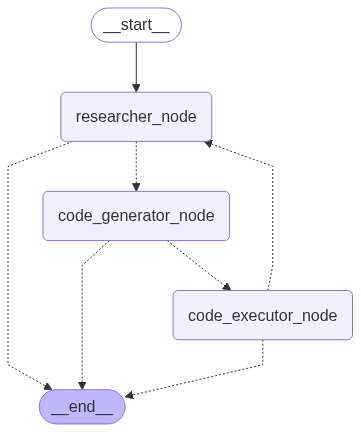

In [77]:
workflow.compile()

In [78]:
response = app.invoke({"messages": [("user", "Generate a chart showing the population growth of India over the last 5 years.")]})

<class 'langgraph.pregel.io.AddableValuesDict'>
{'messages': [HumanMessage(content='Generate a chart showing the population growth of India over the last 5 years.', additional_kwargs={}, response_metadata={}, id='c6abf0ce-2c25-4d3e-8266-e85a2ba9c2a8'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_9vrs5ZjJHytXRbNlXGmSJys3', 'function': {'arguments': '{"query":"India population growth data last 5 years"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 803, 'total_tokens': 826, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff25b2783a', 'id': 'chatcmpl-C3jW3d2QhYPKgjoTvY7neDUNwRwkS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': N

AttributeError: 'AIMessage' object has no attribute 'lower'